In [116]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
import seaborn as sns
from torch.nn import MSELoss
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.utils.tensorboard import SummaryWriter
from sklearn.inspection import PartialDependenceDisplay

from sklearn.base import BaseEstimator, RegressorMixin

In [104]:
writer = SummaryWriter(f"runs/PDP")

In [153]:
X, y, coef = make_regression(n_samples=5000, n_features=20, random_state=42, coef=True)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2)

trainval_dataset = TensorDataset(X_train_val, y_train_val)

In [163]:
pd.DataFrame([coef], index=["coef"]).T.sort_values(["coef"], ascending=False)

,coef
1,82.846603
16,78.467952
17,68.280113
14,57.000133
13,48.244771
19,29.506960
8,25.379334
10,19.365118
15,8.889189
18,1.855930


<Axes: ylabel='Count'>

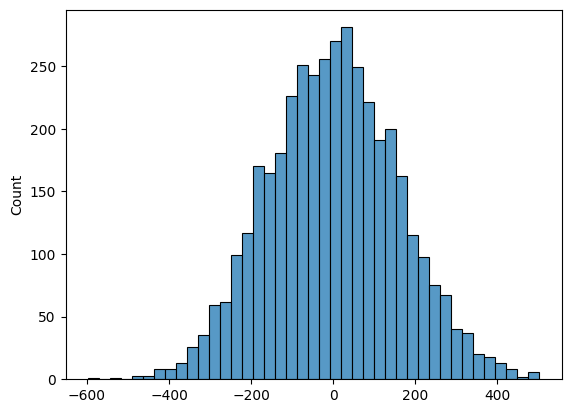

In [106]:
sns.histplot(y_train_val.flatten())

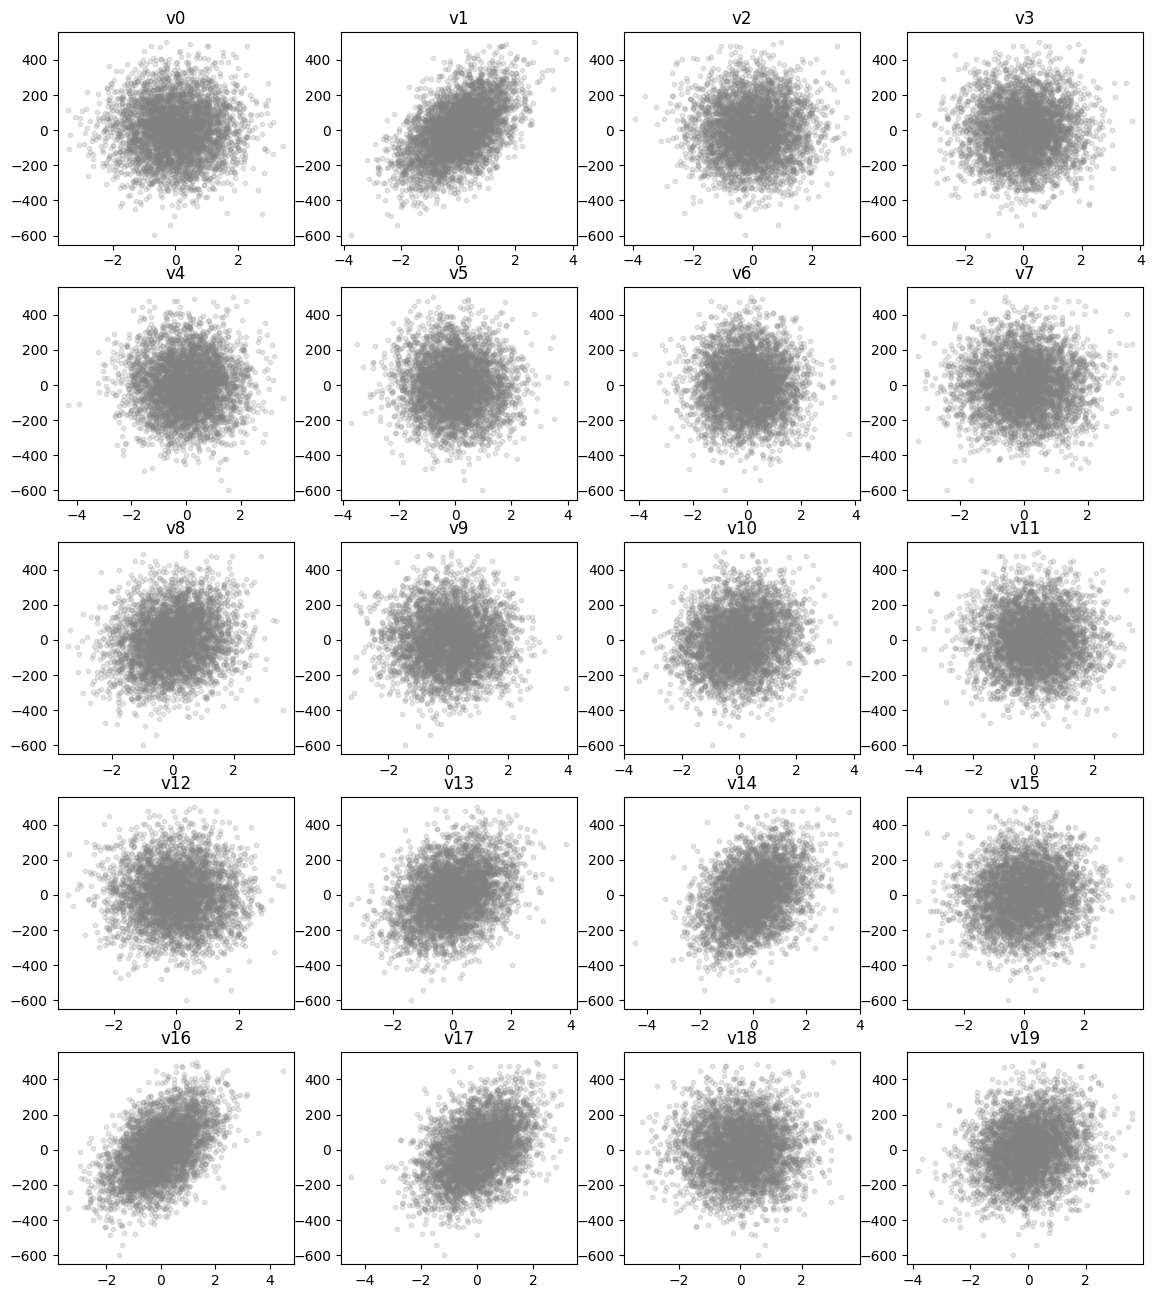

In [107]:
fig, axs = plt.subplots(5, 4, figsize=(14, 16))
axs = axs.flatten()

for feature_idx in range(20):
    axs[feature_idx].scatter(X_train_val[:, feature_idx], y_train_val, alpha=0.2, color='gray', s=10)
    axs[feature_idx].set_title(f"v{feature_idx}")


In [108]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(20, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_epoch = None

    def forward(self, x):
        x = self.model(x)
        return x

In [109]:
def train_new_model(fold: int, epochs: int, train_loader: DataLoader, val_loader: DataLoader, save_dir: Path | None):
    model = Model()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = MSELoss()

    print("Fold: ", fold)

    train_loss_per_epoch = np.zeros(epochs)
    val_loss_per_epoch = np.zeros(epochs)
    best_val_loss = 99999999.9

    for epoch in range(epochs):
        total_train_loss = 0.0
        total_val_loss = 0.0

        model.train()
        for data, target in train_loader:
            optimizer.zero_grad()

            output = model(data)
            loss = loss_fn(output, target)

            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                loss = loss_fn(output, target)
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        print(f"{fold=} {epoch=} {avg_train_loss=:.3f} {avg_val_loss=:.3f}")

        train_loss_per_epoch[epoch] = avg_train_loss
        val_loss_per_epoch[epoch] = avg_val_loss

        writer.add_scalar(f"Loss/train/fold{fold}", avg_train_loss, epoch)
        writer.add_scalar(f"Loss/val/fold{fold}", avg_val_loss, epoch)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            if save_dir:
                torch.save(model.state_dict(), save_dir / f"fold{fold}.pth")

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_epoch = val_loss_per_epoch

    return model


In [110]:
def train_models_cv5(epochs: int, save_dir: Path | None) -> nn.ModuleList:
    cv = KFold()

    val_losses = 0.0

    models = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_val, y_train_val)):
        train_loader = DataLoader(Subset(trainval_dataset, train_idx), batch_size=256, shuffle=True)
        val_loader = DataLoader(Subset(trainval_dataset, val_idx), batch_size=256, shuffle=True)
        model = train_new_model(fold, epochs, train_loader, val_loader, save_dir)

        best_val_loss = model.val_loss_per_epoch.min().item()
        val_losses += best_val_loss

        models.append(model)

    return nn.ModuleList(models)

In [111]:
save_dir = Path("checkpoints/best")
save_dir.mkdir(parents=True, exist_ok=True)
models = train_models_cv5(300, save_dir)

Fold:  0
fold=0 epoch=0 avg_train_loss=25008.083 avg_val_loss=22528.937
fold=0 epoch=1 avg_train_loss=24764.115 avg_val_loss=23658.735
fold=0 epoch=2 avg_train_loss=24565.263 avg_val_loss=24249.202
fold=0 epoch=3 avg_train_loss=23674.319 avg_val_loss=21746.991
fold=0 epoch=4 avg_train_loss=22668.245 avg_val_loss=19963.976
fold=0 epoch=5 avg_train_loss=21361.683 avg_val_loss=19859.759
fold=0 epoch=6 avg_train_loss=19533.108 avg_val_loss=19329.385
fold=0 epoch=7 avg_train_loss=17497.941 avg_val_loss=14506.250
fold=0 epoch=8 avg_train_loss=15181.665 avg_val_loss=13789.167
fold=0 epoch=9 avg_train_loss=13088.263 avg_val_loss=11250.499
fold=0 epoch=10 avg_train_loss=11056.195 avg_val_loss=10858.532
fold=0 epoch=11 avg_train_loss=9096.869 avg_val_loss=8277.256
fold=0 epoch=12 avg_train_loss=7318.847 avg_val_loss=6276.467
fold=0 epoch=13 avg_train_loss=5835.188 avg_val_loss=5124.547
fold=0 epoch=14 avg_train_loss=4528.254 avg_val_loss=3551.168
fold=0 epoch=15 avg_train_loss=3456.988 avg_val_l

In [136]:
class MyWrapper(RegressorMixin, BaseEstimator):
    def __init__(self, models: nn.ModuleList):
        self.models = models
        self.models.eval()
        self.is_fitted_ = True

    def fit(self, X, y):
        raise NotImplementedError()

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(X)
            y = torch.stack([model(X) for model in self.models]).mean(dim=0)
            return y.numpy()


In [137]:
clf = MyWrapper(models)
ind = range(6, 10)
clf.predict(X_test[ind]), y_test[ind]
clf.score(X_test, y_test)

/tmp/ipykernel_24808/3934482644.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)


0.9999964237213135

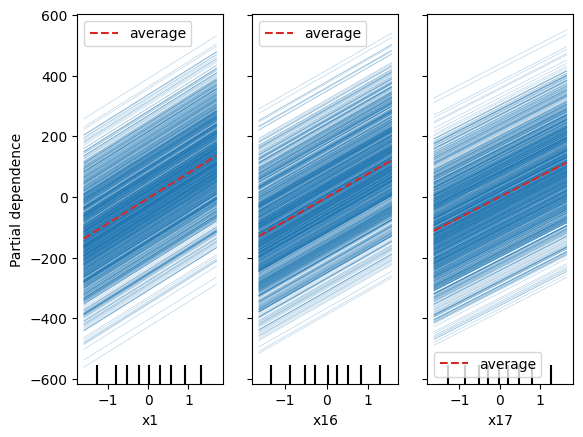

In [151]:
PartialDependenceDisplay.from_estimator(clf, X_test.numpy(), features=[1, 16, 17], kind='both', pd_line_kw={"color": "tab:red"})

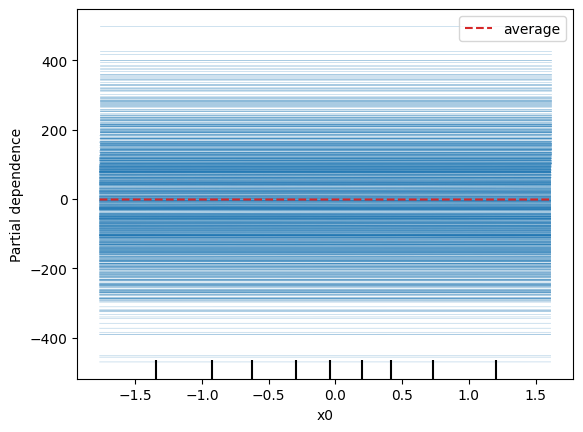

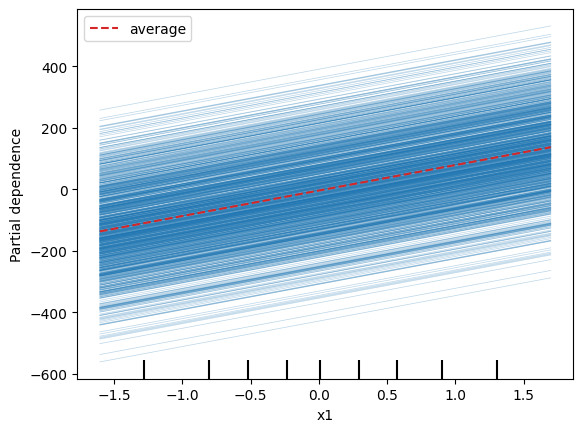

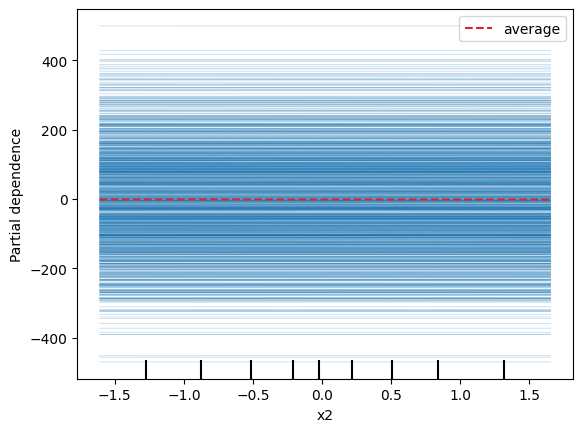

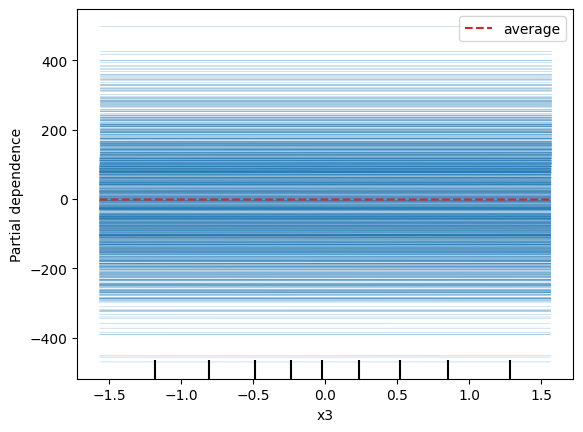

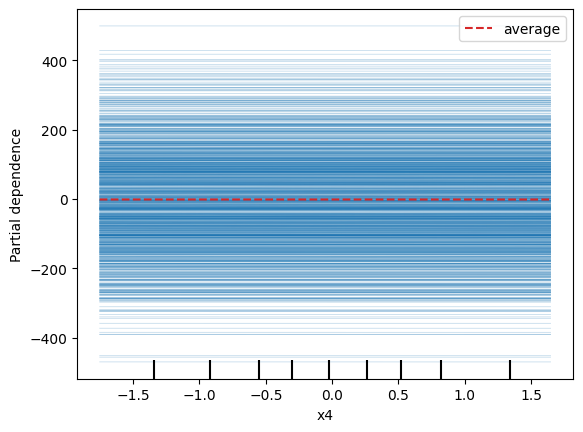

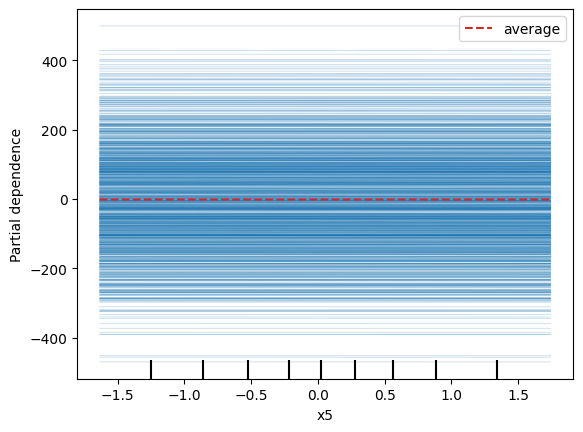

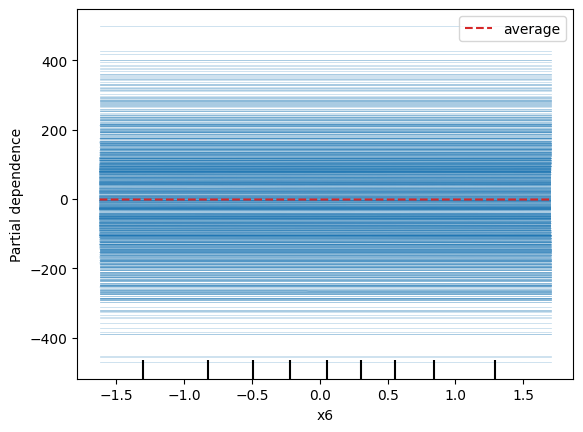

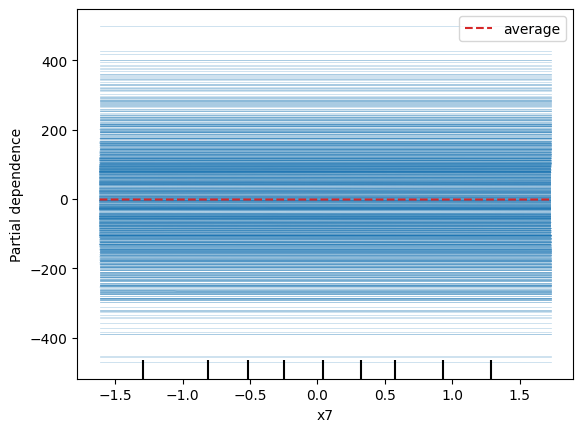

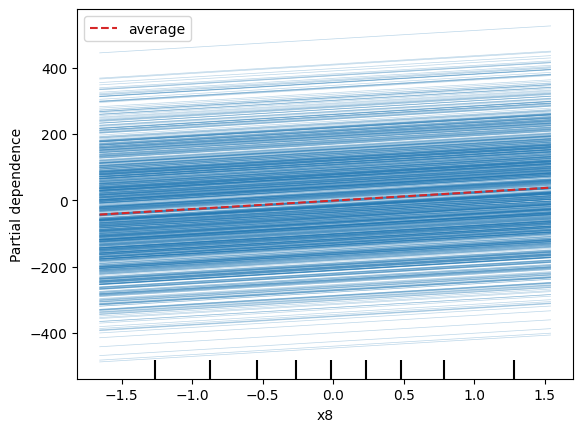

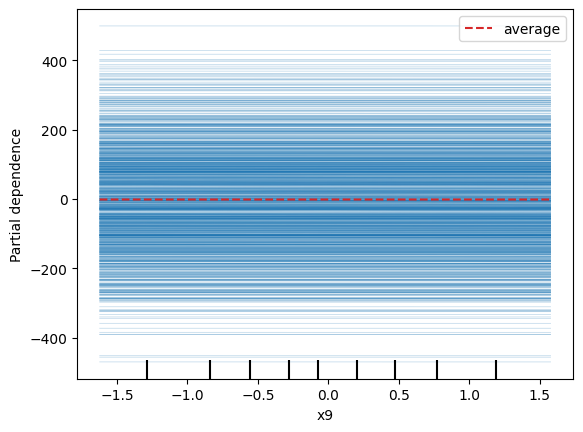

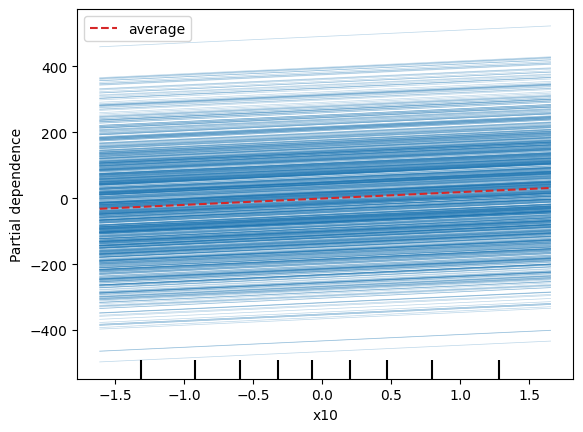

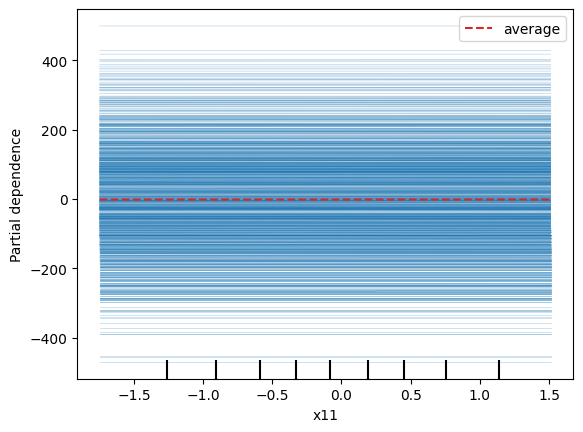

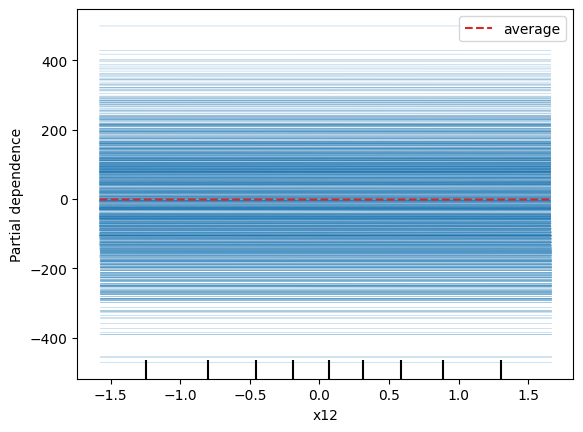

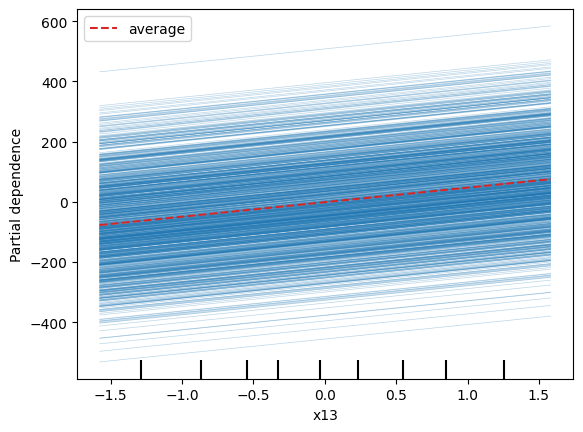

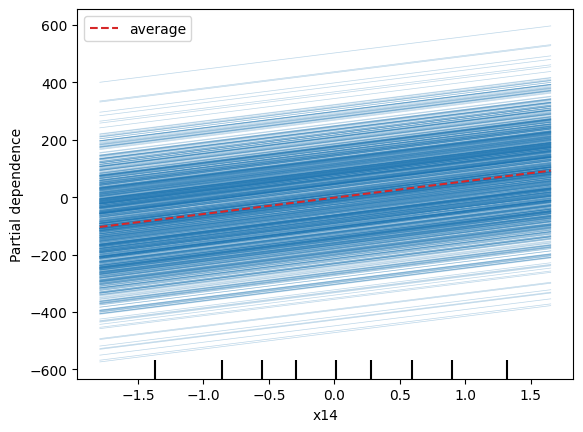

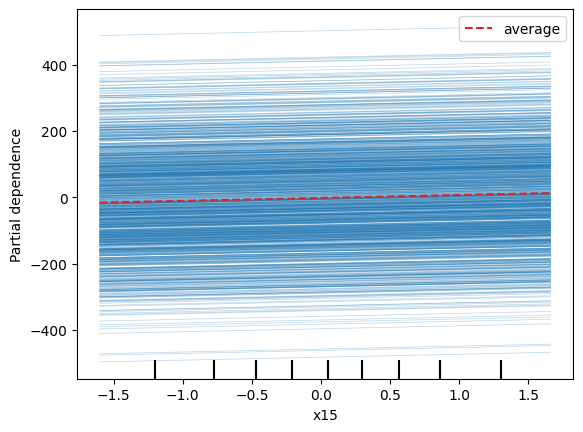

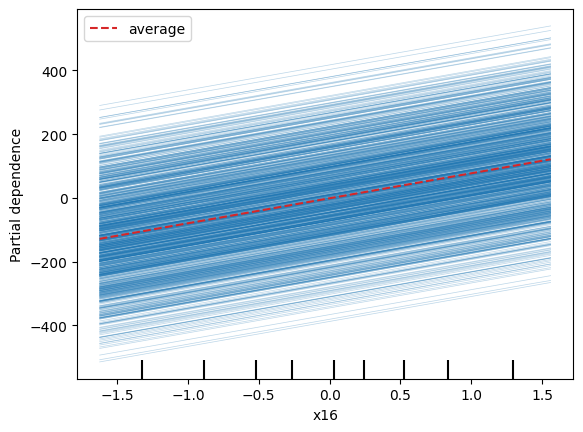

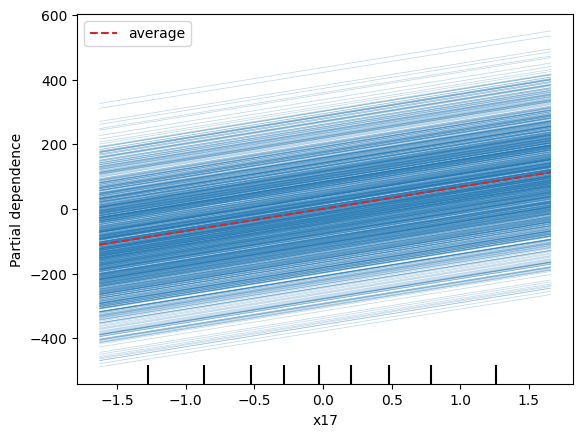

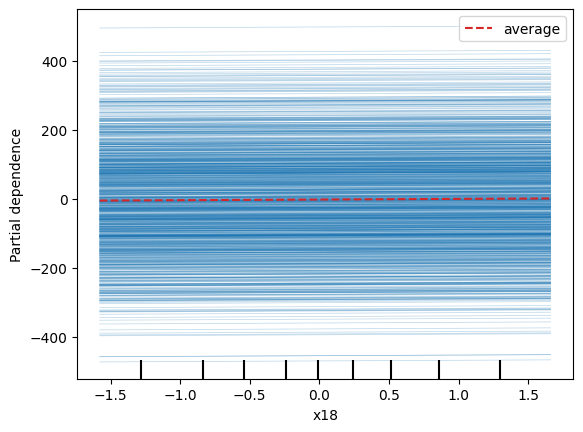

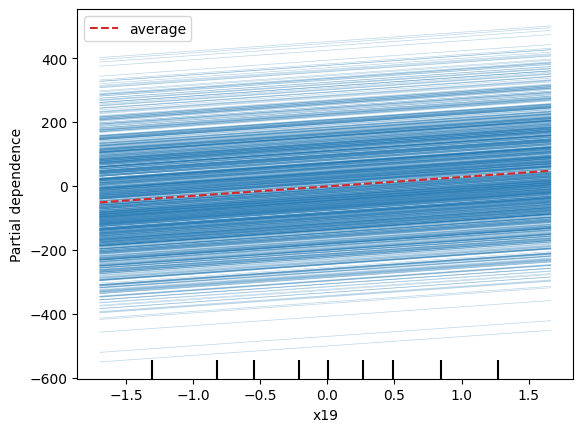

In [152]:
for i in range(20):
    PartialDependenceDisplay.from_estimator(clf, X_test.numpy(), features=[i], kind='both', pd_line_kw={"color": "tab:red"})
    plt.show()